# 🔍 RepoLens — Main End-to-End Orchestrator
**Single Driver Notebook for Codebase Ingestion, Git History & Agentic Q&A**

- 🧠 **Models (`src/agent/models.py`)**: Centralized Reasoning LLM, Fast Router, and Local HuggingFace Embeddings.
- 💾 **Checkpoints & Threads (`src/agent/checkpoint.py`)**: Multi-turn conversation sessions with in-memory or SQLite persistence.
- 🌳 **Deterministic Tree & Router (`src/ingestion/tree_indexer.py`)**: Zero-hallucination folder & commit DAG lookups.

### 1. Load Environment & Import Modular Helpers from `src/`

In [35]:
import os
import sys
from pathlib import Path
import dotenv
from IPython.display import Image, display

# Ensure project root is in python path
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Load .env
dotenv.load_dotenv(repo_root / ".env")

# 1. Models Factory
from src.agent.models import get_reasoning_llm, get_fast_router_llm, get_embeddings_model

# 2. Checkpointer & Session Management
from src.agent.checkpoint import get_checkpointer, create_thread_config, get_thread_history

# 3. Ingestion & RAG
from src.ingestion.pipeline import clone_or_load_repo, parallel_scan_and_chunk
from src.rag.vectorstore import load_or_build_vectorstore
from src.agent.main_graph import create_code_agent

print("✅ All RepoLens modules (Models, Checkpoints, RAG & Ingestion) imported cleanly.")

✅ All RepoLens modules (Models, Checkpoints, RAG & Ingestion) imported cleanly.


### 2. Initialize Models & Checkpointer Engine

In [36]:
# Initialize Groq Reasoning LLM & Offline Embeddings
llm = get_reasoning_llm()
embeddings = get_embeddings_model()

# Initialize Checkpointer (set use_disk_persistence=True for SQLite disk storage)
checkpointer = get_checkpointer(use_disk_persistence=False)

print("🚀 Models & Checkpointer initialized successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

🚀 Models & Checkpointer initialized successfully!


### 3. Ingest Repository (GitHub URL or Local Directory)

In [37]:
# 🎯 Paste ANY public GitHub repository URL or use 'local' / '.'
TARGET_REPO = "https://github.com/psf/requests.git"
FORCE_REINDEX = False

print(f"📂 Resolving and indexing: {TARGET_REPO}...")
vectorstore = load_or_build_vectorstore(
    repo_source=TARGET_REPO,
    embeddings=embeddings,
    force_reindex=FORCE_REINDEX
)
print("✨ Ingestion and Vector Store ready!")

📂 Resolving and indexing: https://github.com/psf/requests.git...
[CLONING] Cloning https://github.com/psf/requests.git (depth=50)...
[CLONING COMPLETE] E:\Learning\Campusx GenAI\RepoLens\cloned_repos\requests
[PARSING] Scanning 117 files using 32 threads...
[PARSING COMPLETE] Generated 412 semantic code chunks.
[GIT INGESTION] Extracting up to 50 commits with diffs...
[GIT PARSER] Extracted 50 commit history documents.
[GIT COMPLETE] Added 50 commit history records.
[EMBEDDING] Encoding chunks & constructing FAISS vector index...
[INDEX PERSISTED] Saved FAISS vector store to E:\Learning\Campusx GenAI\RepoLens\.indexes\requests_2652ff29a355
✨ Ingestion and Vector Store ready!


### 4. Compile LangGraph Code Reasoning Agent

In [38]:
# Compile the agent with dynamic router and checkpointer memory
agent_app = create_code_agent(
    llm=llm,
    vectorstore=vectorstore,
    repo_path=repo_root,
    top_k=6,
    checkpointer=checkpointer
)
print("🤖 RepoLens Agent compiled successfully.")

🤖 RepoLens Agent compiled successfully.


### 📊 Visualize LangGraph Agent Architecture
Run this cell to display the visual Mermaid StateGraph architecture diagram.

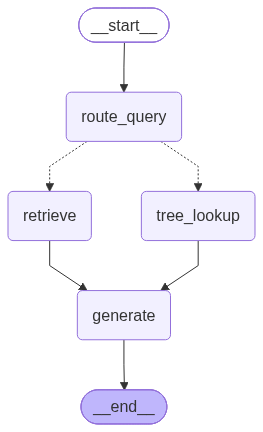

In [39]:
try:
    display(Image(agent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Mermaid PNG render failed ({e}), displaying ASCII graph:\n")
    print(agent_app.get_graph().draw_ascii())

### 5. Interactive Multi-Turn Chat with Thread Session Management

In [40]:
def ask_repo(question: str, session_id: str = "user_session_1"):
    """
    Queries RepoLens using a specific thread_id to preserve conversation memory.
    """
    config = create_thread_config(thread_id=session_id)
    result = agent_app.invoke({
        "question": question,
        "route": None,
        "retrieved_docs": [],
        "tree_context": None,
        "answer": "",
        "citations": []
    }, config=config)
    
    print("\n==================== REPOLENS RESPONSE ====================")
    print(result["answer"])
    print("\n--- Sources & Citations ---")
    if result.get("citations"):
        for c in sorted(result["citations"]):
            print(f"  * {c}")
    else:
        print("  (No direct citations returned)")
    print("===========================================================\n")

# Sample Query 1: Structural Tree Query
ask_repo("What is the directory structure of this repository and where are the main packages?")

# Sample Query 2: Code Implementation Query (Maintains session memory in user_session_1)
ask_repo("Explain the Session class and how requests handles cookies.")

RateLimitError: Error code: 429 - {'error': {'message': "Request too large for model `qwen/qwen3.8-27b` in organization `org_01m0sqd5gxepttz68ctxy655r8` service tier `on_demand` on output tokens per minute (OTPM): Limit 1000, Requested 1529. The request's expected output tokens exceed the enforced limit; reduce max_tokens (or the request's expected output) and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing", 'type': 'tokens', 'code': 'rate_limit_exceeded'}}